## 1. What this notebook computes

The previous notebooks of this chapter showed that the canonical rule
$\{\Psi_A, \Psi^\dagger_C\} = B_{AC}$ (at one point) forces an indefinite inner
product when $\Psi^\dagger$ is read as the Hilbert adjoint. The Revision record shows
that in the *good sector* (waves that do not depend on the extra times $x_5, x_6,
x_7$) a POSITIVE quantum state space exists for each momentum. This notebook builds
it, for one momentum at a time, and checks every recorded number:

- the mode Hamiltonian $h$ of a good-sector momentum is Hermitian, with eigenvalues
  $+E$ and $-E$ (eight each), $E = \sqrt{m^2 + k_1^2 + k_2^2 + k_3^2 + k_8^2}$;
- the field is expanded in particle operators $b_s$ and antiparticle operators
  $d_s$ on a positive Fock space, and the canonical conjugate is realised as
  $\Psi^\dagger = \chi B$ with $\chi$ the Hilbert adjoint; then
  $\{\Psi_A, \Psi^\dagger_C\} = B_{AC}$ holds;
- the vacuum (the *filled Dirac sea*) has energy $-8E$; after *normal ordering* a
  particle and an antiparticle both have energy $+E$, and charges $+1$ and $-1$;
- the expectation-value rule $\langle{:}\Psi^\dagger M\Psi{:}\rangle = u^\dagger BMu$
  for a particle and $-v^\dagger BMv$ for an antiparticle;
- all $2^{16} = 65536$ occupation patterns of one momentum, counted by energy and
  charge;
- the contrast with the classical COMMUTING field dirac16complex00, which has no Fock
  space and no normal ordering: its positive-frequency waves have energy densities of
  both signs, so its energy is unbounded below.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 10c (The good sector: a positive Fock space for one momentum) is the file
`Revision/textbook/notebooks/10c_good_sector_fock.ipynb` of the repository Dirac_claude.
For one momentum without extra-time components (the good sector) it computes the
orthonormal eigenvectors of the Hermitian mode Hamiltonian, expands the field in particle
and antiparticle operators on a positive fermionic Fock space with the canonical
conjugate realised as chi B, and checks the canonical anticommutator, the vacuum energy
of the filled Dirac sea (minus 8 E), the normal-ordered energies (plus E for particles
and for antiparticles), the charges (plus 1 and minus 1) and the expectation-value rule,
for the two exact examples of the Revision record; it counts the states of all 65536
occupation patterns by energy and charge, and contrasts the quantised fermion with the
classical commuting field dirac16complex00, whose energy is unbounded below; five
teaching figures. It needs a computer with Windows 11, macOS or Linux, an internet
connection for the installation, the program Git, and Python 3.12 or newer (the notebooks
were built with Python 3.14.5) with these packages at exactly these versions: numpy
2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4,
nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy
and matplotlib; the other packages run Jupyter, the program that shows and runs
notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 10c_good_sector_fock.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 15 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 10c_good_sector_fock.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
10c_good_sector_fock.ipynb` (in the same folder, without running the cells again) to read
the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/10c.captions.json`
- `Revision/textbook/figures/10c_1_expectation_rule.png`
- `Revision/textbook/figures/10c_2_dirac_sea.png`
- `Revision/textbook/figures/10c_3_fock_spectrum.png`
- `Revision/textbook/figures/10c_4_commuting_energy.png`
- `Revision/textbook/figures/10c_5_energy_density_spread.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS the figure file 10c_5_energy_density_spread.png exists
    ALL 14 CHECKS PASSED (notebook 10c)

and the notebook must show 5 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/10c_good_sector_fock.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" for gammas.json: the notebook reads one file of the repository; it
  must be opened inside the folder Revision/textbook/notebooks of a complete copy of the
  repository. Clone the repository again and open the notebook there.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 10c (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 10c (The good sector: a positive Fock space for one momentum) is the file
# Revision/textbook/notebooks/10c_good_sector_fock.ipynb of the repository Dirac_claude.
# For one momentum without extra-time components (the good sector) it computes the
# orthonormal eigenvectors of the Hermitian mode Hamiltonian, expands the field in
# particle and antiparticle operators on a positive fermionic Fock space with the
# canonical conjugate realised as chi B, and checks the canonical anticommutator, the
# vacuum energy of the filled Dirac sea (minus 8 E), the normal-ordered energies (plus E
# for particles and for antiparticles), the charges (plus 1 and minus 1) and the
# expectation-value rule, for the two exact examples of the Revision record; it counts
# the states of all 65536 occupation patterns by energy and charge, and contrasts the
# quantised fermion with the classical commuting field dirac16complex00, whose energy is
# unbounded below; five teaching figures. It needs a computer with Windows 11, macOS or
# Linux, an internet connection for the installation, the program Git, and Python 3.12 or
# newer (the notebooks were built with Python 3.14.5) with these packages at exactly
# these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab
# 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The
# notebook itself imports numpy and matplotlib; the other packages run Jupyter, the
# program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 10c_good_sector_fock.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 15
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 10c_good_sector_fock.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 10c_good_sector_fock.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/10c.captions.json
# - Revision/textbook/figures/10c_1_expectation_rule.png
# - Revision/textbook/figures/10c_2_dirac_sea.png
# - Revision/textbook/figures/10c_3_fock_spectrum.png
# - Revision/textbook/figures/10c_4_commuting_energy.png
# - Revision/textbook/figures/10c_5_energy_density_spread.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS the figure file 10c_5_energy_density_spread.png exists
#     ALL 14 CHECKS PASSED (notebook 10c)
#
# and the notebook must show 5 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/10c_good_sector_fock.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" for gammas.json: the notebook reads one file of the repository;
#   it must be opened inside the folder Revision/textbook/notebooks of a complete copy of
#   the repository. Clone the repository again and open the notebook there.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "10c"  # this notebook: chapter 10, example c


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 10c complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Good sector**: no momentum along the extra times, $k_5 = k_6 = k_7 = 0$.
- **Mode Hamiltonian** $h$: the $16 \times 16$ matrix with $i\,du/dx_4 = hu$ for a
  plane wave $u\,e^{ik\cdot x}$ (built in the first notebook of this chapter); its
  eigenvalues are the frequencies, read as energies.
- **Orthonormal**: columns $u_s$ with $u_s^\dagger u_{s'} = 1$ for $s = s'$ and 0
  otherwise. **Completeness**: 16 orthonormal columns $w_1, \dots, w_{16}$ satisfy
  $\sum_n w_n w_n^\dagger = I_{16}$.
- **Particle, antiparticle**: a quantum of positive energy created by $b_s^*$, and
  a quantum created by $d_s^*$, which is a hole in the filled negative-energy levels.
- **Dirac sea**: the picture in which every negative-energy level is filled in the
  vacuum. Its energy, $-E$ for each of the 8 negative levels, is $-8E$.
- **Normal ordering**: writing every product with the annihilators to the right, by
  definition dropping the constant that the reordering produces (here $-8E$ for the
  energy). The normal-ordered value of an operator $X$ in a state is its value minus
  the vacuum value.
- **Charge**: the conserved U(1) charge $Q = \Psi^\dagger B\Psi$ of the field.
- **Expectation value**: $\langle\phi|X|\phi\rangle$ in a normalised state $\phi$.
- **Fock space, pattern, vacuum, $f_p$, $f_p^*$**: as in the previous notebook of
  this chapter: a basis state is a pattern of occupations of 16 fermion modes,
  stored as a whole number whose binary digit $p$ is the occupation of mode $p$.
- **dirac16complex00**: the second field of the theory, with 16 COMMUTING complex
  components; it is a classical field (it is not quantised).
- **Energy density**: $\rho = -T^{x_4}{}_{x_4}$, the time-time component of the
  energy-momentum tensor with the sign convention of the Revision record.

## 4. The physical and mathematical situation

**One good-sector momentum.** In the good sector $h = m\beta + \sum_{a}k_a\alpha^a$
with $\beta = -i\gamma^{(x_4)}$ and $\alpha^a = -\gamma^{(x_4)}\gamma^{(x_a)}$ for
$a = 1, 2, 3, 8$; all five matrices are Hermitian, so $h$ is Hermitian and has real
eigenvalues; $h^2 = E^2 I_{16}$ and $\mathrm{tr}\,h = 0$ give eight eigenvalues $+E$
and eight $-E$. Choose orthonormal eigenvectors $u_1, \dots, u_8$ ($hu_s = Eu_s$) and
$v_1, \dots, v_8$ ($hv_s = -Ev_s$). Eigenvectors of a Hermitian matrix for different
eigenvalues are orthogonal, so the 16 columns are orthonormal, and the matrix $W$
with these columns obeys $WW^\dagger = I_{16}$ (completeness).

**The field.** On a positive Fock space with operators $b_s, d_s$ ($\{b_s, b_{s'}^*\}
= \{d_s, d_{s'}^*\} = \delta_{ss'}$, all other anticommutators zero) put

$$\Psi = \sum_s (u_s b_s + v_s d_s^*),\qquad \chi = \sum_s (u_s^\dagger b_s^* +
v_s^\dagger d_s),\qquad \Psi^\dagger = \chi B .$$

Here $\chi$ is the Hilbert adjoint of $\Psi$. Line by line:
$\{\Psi_A, \chi_C\} = \sum_s (u_s)_A(u_s)_C^* + \sum_s (v_s)_A(v_s)_C^* =
(WW^\dagger)_{AC} = \delta_{AC}$, and therefore $\{\Psi_A, \Psi^\dagger_C\} = \sum_D
\{\Psi_A, \chi_D\}B_{DC} = B_{AC}$: the canonical rule.

**The energy.** The Hamiltonian of the momentum is $\Psi^\dagger h'\Psi$ with
$h' = mC - i\sum_a k_aC\gamma^{(x_a)}$, and $Bh' = h$ (previous notebook), so it
equals $\chi h\Psi$. Insert the expansion; $hu_s = Eu_s$, $hv_s = -Ev_s$ and the
orthonormality leave

$$\chi h\Psi = \sum_s E\,b_s^*b_s - \sum_s E\,d_sd_s^* = \sum_s E\,(b_s^*b_s +
d_s^*d_s) - 8E,$$

where the last step used $d_sd_s^* = 1 - d_s^*d_s$ for each of the 8 values of $s$.
The vacuum ($b_s|0\rangle = d_s|0\rangle = 0$) has energy $-8E$; after normal
ordering every particle and every antiparticle has energy $+E > 0$.

**The charge.** $Q = \Psi^\dagger B\Psi = \chi BB\Psi = \chi\Psi = \sum_s(b_s^*b_s +
d_sd_s^*) = \sum_s(b_s^*b_s - d_s^*d_s) + 8$: after normal ordering particles have
charge $+1$ and antiparticles $-1$.

**The commuting field.** For dirac16complex00 there is no Fock space and no
normal ordering. For a plane wave $\Phi = c\,u\,e^{i(k\cdot x - Ex_4)}$ with
$hu = Eu$ the energy density is $\rho = E\,|c|^2\,u^\dagger Bu$ (derived in
Section 10), and $u^\dagger Bu$ takes both signs on the eigenspace of $+E$: the
classical energy is unbounded below.

## 5. The gamma matrices, $B$ and the mode Hamiltonian

The next cell reads the gammas, builds $C$ and $B$, defines the mode Hamiltonian
$h$ of a good-sector momentum and the helper `check_record` (the PASS line and the
line of the reproduced Revision record are printed in one piece, so that the stored
output is the same in every run), and the colours of the figures.

In [2]:
import contextlib  # lets a block of code print into a text buffer
import io  # the text buffer
import sys  # the screen output, sys.stdout

import numpy as np  # numbers, arrays and matrices


def check_record(condition, name, record):
    """check(condition, name, record=record), printed in one piece."""
    buffer = io.StringIO()
    with contextlib.redirect_stdout(buffer):  # what check prints goes to buffer
        check(condition, name, record=record)
    sys.stdout.write(buffer.getvalue())  # one single piece of output


BLUE, ORANGE, GREEN, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#52514e"
fixture = json.loads(repository_file("Revision/algebra/gammas.json").read_text(
    encoding="utf-8"))
gamma = {a: np.array(fixture["gamma"][a - 1], dtype=int) for a in range(1, 9)}
C = gamma[8] @ gamma[1] @ gamma[2] @ gamma[3]  # the author's sigma16
B = -1j * (C @ gamma[4])  # B = -i C gamma^(x4)


def mode_hamiltonian(m, k):
    """h = -i m gamma^(x4) - gamma^(x4) sum_a k_a gamma^(x_a); k = {a: k_a}."""
    h = -1j * m * gamma[4]
    for a, k_a in k.items():
        h = h - k_a * (gamma[4] @ gamma[a])
    return h


def orthonormal_columns(P):
    """Orthonormal columns that span the range of P (Gram-Schmidt, done twice)."""
    basis = []
    for column in P.T:
        v = column.astype(complex)
        for _ in range(2):
            for e in basis:
                v = v - (e.conj() @ v) * e
        length = np.sqrt((v.conj() @ v).real)
        if length > 1e-8:
            basis.append(v / length)
    return np.array(basis).T


say("gammas, C, B and the mode Hamiltonian are ready")

gammas, C, B and the mode Hamiltonian are ready


## 6. One good-sector momentum: $m = 2$, $k = (1, 2, 0, 4)$, $E = 5$

The sympy verifier of the Revision record uses the mass $m = 2$ and the momenta
$k_1 = 1$, $k_2 = 2$, $k_3 = 0$, $k_8 = 4$, so $E = \sqrt{4 + 1 + 4 + 0 + 16} = 5$.
The next cell builds $h$, checks that it is Hermitian, that $h^2 = 25 I_{16}$ and
that it commutes with $B$, and computes the eigenvectors as the orthonormal columns
of the projectors $\frac12(I \pm h/E)$ (the same procedure as in the first notebook
of this chapter). It then checks orthonormality and completeness, $W^\dagger W =
WW^\dagger = I_{16}$, where $W = (u_1, \dots, u_8, v_1, \dots, v_8)$.

In [3]:
def good_sector_modes(m, k):
    """E, and the matrix W whose columns are u_1..u_8 (energy +E), v_1..v_8 (-E)."""
    h = mode_hamiltonian(m, k)
    E = np.sqrt(m ** 2 + sum(k_a ** 2 for k_a in k.values()))  # no extra times
    U_plus = orthonormal_columns((np.eye(16) + h / E) / 2)
    V_minus = orthonormal_columns((np.eye(16) - h / E) / 2)
    return h, E, np.hstack([U_plus, V_minus])


h, E, W = good_sector_modes(2, {1: 1, 2: 2, 8: 4})
report("E for m = 2, k = (1, 2, 0, 4)", f"{E:.12f}")
hermitian = np.max(np.abs(h - h.conj().T)) < 1e-15
square_ok = np.max(np.abs(h @ h - 25 * np.eye(16))) < 1e-13
commutes = np.max(np.abs(B @ h - h @ B)) < 1e-15
eigen_ok = (np.max(np.abs(h @ W[:, :8] - E * W[:, :8])) < 1e-13
            and np.max(np.abs(h @ W[:, 8:] + E * W[:, 8:])) < 1e-13)
complete = (np.max(np.abs(W.conj().T @ W - np.eye(16))) < 1e-13
            and np.max(np.abs(W @ W.conj().T - np.eye(16))) < 1e-13)
say(f"h Hermitian: {hermitian}, h^2 = 25 I: {square_ok}, B h = h B: {commutes}")
say(f"8 + 8 eigenvectors: {eigen_ok}; orthonormal and complete: {complete}")
check(hermitian and square_ok and commutes and eigen_ok and complete
      and W.shape == (16, 16),
      "good sector: h Hermitian, h^2 = E^2, 8 + 8 orthonormal complete eigenvectors")

RESULT E for m = 2, k = (1, 2, 0, 4) = 5.000000000000
h Hermitian: True, h^2 = 25 I: True, B h = h B: True
8 + 8 eigenvectors: True; orthonormal and complete: True
PASS good sector: h Hermitian, h^2 = E^2, 8 + 8 orthonormal complete eigenvectors


## 7. The positive Fock space and the field operators

The next cell copies the fermionic Fock space of the previous notebook (states are
dictionaries `{pattern: amplitude}`; `annihilate(p, state)` is $f_p$ and
`create(p, state)` is $f_p^*$, with the sign that makes different modes
anticommute). The 16 modes are used as follows: modes $p = 0, \dots, 7$ are the
particles, $b_{s} = f_{s-1}$; modes $p = 8, \dots, 15$ are the antiparticles,
$d_s = f_{s+7}$. The field $\Psi = \sum_s (u_sb_s + v_sd_s^*)$ is then
$\Psi_A = \sum_p W_{Ap}F_p$ with $F_p = f_p$ for $p < 8$ and $F_p = f_p^*$ for
$p \geq 8$, and its Hilbert adjoint is $\chi_A = \sum_p W_{Ap}^*F_p^*$.

Every operator of the form $\chi N\Psi = \sum_{A,C}\chi_A N_{AC}\Psi_C$ becomes
$\sum_{p,q} (W^\dagger NW)_{pq}F_p^*F_q$; the function `bilinear(N, state)` applies
it to a state. The cell checks $\{\Psi_A, \chi_C\} = \delta_{AC}$ and
$\{\Psi_A, \Psi^\dagger_C\} = B_{AC}$ on a random state.

In [4]:
def sign_below(n, p):
    """(-1) to the power of the number of occupied modes below mode p in pattern n."""
    return -1 if bin(n & ((1 << p) - 1)).count("1") % 2 else 1


def annihilate(p, state):  # f_p
    result = {}
    for n, amplitude in state.items():
        if n >> p & 1:
            new = n ^ (1 << p)
            result[new] = result.get(new, 0) + sign_below(n, p) * amplitude
    return result


def create(p, state):  # f_p^*
    result = {}
    for n, amplitude in state.items():
        if not n >> p & 1:
            new = n | (1 << p)
            result[new] = result.get(new, 0) + sign_below(n, p) * amplitude
    return result


def add(*terms):
    """The state sum of coefficient * state over the pairs (coefficient, state)."""
    result = {}
    for coefficient, state in terms:
        for n, amplitude in state.items():
            result[n] = result.get(n, 0) + coefficient * amplitude
    return result


def inner(left, right):
    """The positive inner product <left|right>."""
    return sum(np.conj(a) * right.get(n, 0) for n, a in left.items())


def largest(state):
    return max((abs(a) for a in state.values()), default=0.0)


def F(p, state):  # F_p: b (p < 8) or d^* (p >= 8)
    return annihilate(p, state) if p < 8 else create(p, state)


def F_star(p, state):  # the Hilbert adjoint of F_p
    return create(p, state) if p < 8 else annihilate(p, state)


def bilinear(N, state, modes):
    """chi N Psi = sum_(p,q) (W^dagger N W)_pq F_p^* F_q applied to a state."""
    M = modes.conj().T @ N @ modes
    terms = []
    for q in range(16):
        lowered = F(q, state)
        if lowered:
            terms += [(M[p, q], F_star(p, lowered)) for p in range(16)
                      if abs(M[p, q]) > 1e-15]
    return add(*terms)


def psi(A, state, modes):  # Psi_A = sum_p W_Ap F_p
    return add(*[(modes[A - 1, p], F(p, state)) for p in range(16)])


def chi(A, state, modes):  # chi_A = sum_p conj(W_Ap) F_p^*
    return add(*[(np.conj(modes[A - 1, p]), F_star(p, state)) for p in range(16)])


def psi_dagger(A, state, modes):  # the canonical conjugate: sum_C chi_C B_CA
    return add(*[(B[C_ - 1, A - 1], chi(C_, state, modes)) for C_ in range(1, 17)
                 if B[C_ - 1, A - 1] != 0])


VACUUM = {0: 1.0}
rng = np.random.default_rng(12345)
phi = {int(n): complex(rng.normal(), rng.normal())
       for n in rng.integers(0, 2 ** 16, size=5)}  # a random state
worst_delta, worst_B = 0.0, 0.0
for A in range(1, 17):
    for C_ in range(1, 17):
        with_chi = add((1, psi(A, chi(C_, phi, W), W)), (1, chi(C_, psi(A, phi, W), W)))
        expected = phi if A == C_ else {}
        worst_delta = max(worst_delta, largest(add((1, with_chi), (-1, expected))))
        with_dagger = add((1, psi(A, psi_dagger(C_, phi, W), W)),
                          (1, psi_dagger(C_, psi(A, phi, W), W)))
        worst_B = max(worst_B, largest(add((1, with_dagger), (-B[A - 1, C_ - 1], phi))))
report("largest violation of {Psi_A, chi_C} = delta_AC", f"{worst_delta:.1e}")
report("largest violation of {Psi_A, Psi^dagger_C} = B_AC", f"{worst_B:.1e}")
check(worst_delta < 1e-12 and worst_B < 1e-12,
      "positive Fock space: {Psi, chi} = I and {Psi, Psi^dagger} = B")

RESULT largest violation of {Psi_A, chi_C} = delta_AC = 6.3e-16
RESULT largest violation of {Psi_A, Psi^dagger_C} = B_AC = 6.3e-16
PASS positive Fock space: {Psi, chi} = I and {Psi, Psi^dagger} = B


## 8. Vacuum energy, normal ordering, energies and charges

The next cell computes, on the Fock space:

- the vacuum energy $\langle 0|\chi h\Psi|0\rangle$, which must be $-8E = -40$;
- for each of the 16 one-quantum states $b_s^*|0\rangle$ and $d_s^*|0\rangle$ the
  normal-ordered energy (its energy minus the vacuum energy), which must be $+5$
  for all 16;
- the normal-ordered charge $\chi\Psi$ (the vacuum charge is 8), which must be $+1$
  for the 8 particles and $-1$ for the 8 antiparticles.

In [5]:
def one_quantum_values(N, modes):
    """Normal-ordered values of chi N Psi in the 16 one-quantum states, and the
    vacuum value."""
    vacuum_value = inner(VACUUM, bilinear(N, VACUUM, modes)).real
    values = []
    for p in range(16):  # p < 8: b^*|0>, p >= 8: d^*|0>
        state = create(p, VACUUM)
        values.append(inner(state, bilinear(N, state, modes)).real - vacuum_value)
    return np.array(values), vacuum_value


energies, vacuum_energy = one_quantum_values(h, W)
charges, vacuum_charge = one_quantum_values(np.eye(16), W)
report("vacuum energy (the filled Dirac sea)", f"{vacuum_energy:.10f}")
report("vacuum charge before normal ordering", f"{vacuum_charge:.10f}")
say(f"normal-ordered energies of the 16 quanta: {np.round(energies, 10).tolist()}")
say(f"normal-ordered charges of the 16 quanta:  {np.round(charges, 10).tolist()}")
expected_charges = np.array([1] * 8 + [-1] * 8)  # 8 particles, 8 antiparticles
check_record(abs(vacuum_energy + 40) < 1e-12 and np.max(np.abs(energies - 5)) < 1e-12
             and np.max(np.abs(charges - expected_charges)) < 1e-12,
             "m = 2, k = (1, 2, 0, 4): vacuum -40, every quantum +5, charges +1, -1",
             record="Revision/theory/reports/python-field-theory.json, check "
                    "good_sector_positive_fock_realisation")

RESULT vacuum energy (the filled Dirac sea) = -40.0000000000
RESULT vacuum charge before normal ordering = 8.0000000000
normal-ordered energies of the 16 quanta: [5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0,
    5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0]
normal-ordered charges of the 16 quanta:  [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, -1.0,
    -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0]
PASS m = 2, k = (1, 2, 0, 4): vacuum -40, every quantum +5, charges +1, -1
     reproduces Revision/theory/reports/python-field-theory.json, check
    good_sector_positive_fock_realisation


## 9. The expectation-value rule, and the second recorded example

In the positive realisation every classical bilinear $\Psi^\dagger M\Psi$ becomes
$\chi BM\Psi$. For the particle state $b_s^*|0\rangle$ only the term
$(u_s^\dagger BMu_s)\,b_s^*b_s$ contributes after normal ordering, so the
normal-ordered expectation value is $u_s^\dagger BMu_s$; for the antiparticle state
$d_s^*|0\rangle$ the term $(v_s^\dagger BMv_s)\,d_sd_s^* = (v_s^\dagger BMv_s)(1 -
d_s^*d_s)$ gives $-v_s^\dagger BMv_s$. The next cell checks both for 100 random
complex matrices $M$ and draws the result.

RESULT largest deviation from the rule (100 random M) = 1.8e-15
PASS rule: u^dagger B M u for a particle, -v^dagger B M v for an antiparticle


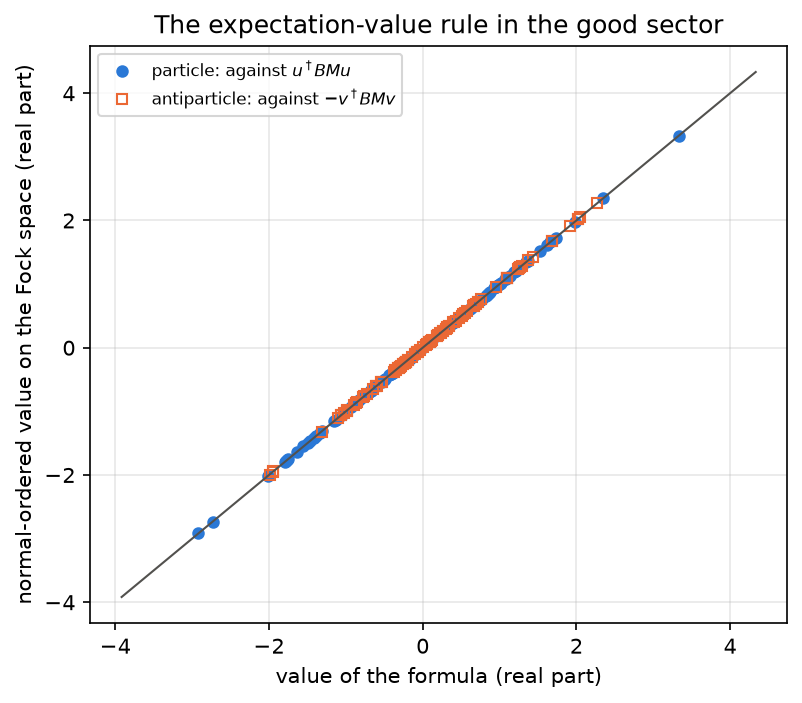

Figure 10c.1 saved as Revision/textbook/figures/10c_1_expectation_rule.png


In [6]:
particle_points, antiparticle_points = [], []
for _ in range(100):
    M = rng.normal(size=(16, 16)) + 1j * rng.normal(size=(16, 16))
    values, _ = one_quantum_values(B @ M, W)  # real parts of <:chi B M Psi:>
    particle_points.append((values[0], (W[:, 0].conj() @ B @ M @ W[:, 0]).real))
    antiparticle_points.append((values[8], -(W[:, 8].conj() @ B @ M @ W[:, 8]).real))
particle_points = np.array(particle_points)
antiparticle_points = np.array(antiparticle_points)
worst = max(np.max(np.abs(particle_points[:, 0] - particle_points[:, 1])),
            np.max(np.abs(antiparticle_points[:, 0] - antiparticle_points[:, 1])))
report("largest deviation from the rule (100 random M)", f"{worst:.1e}")
check(worst < 1e-12,
      "rule: u^dagger B M u for a particle, -v^dagger B M v for an antiparticle")

fig, ax = plt.subplots(figsize=(6.0, 5.0))
ax.plot(particle_points[:, 1], particle_points[:, 0], "o", color=BLUE, markersize=5,
        label="particle: against $u^\\dagger B M u$")
ax.plot(antiparticle_points[:, 1], antiparticle_points[:, 0], "s", color=ORANGE,
        markersize=5, fillstyle="none",
        label="antiparticle: against $-v^\\dagger B M v$")
low = min(particle_points.min(), antiparticle_points.min()) - 1
high = max(particle_points.max(), antiparticle_points.max()) + 1
ax.plot([low, high], [low, high], color=GREY, linewidth=1)
ax.set_xlabel("value of the formula (real part)")
ax.set_ylabel("normal-ordered value on the Fock space (real part)")
ax.set_title("The expectation-value rule in the good sector")
ax.legend(loc="upper left", fontsize=8)
save_figure(fig, "expectation_rule",
            "For 100 random complex $16 \\times 16$ matrices $M$: the normal-ordered "
            "expectation value of the bilinear $\\Psi^\\dagger M\\Psi$ computed on "
            "the positive Fock space of the good-sector momentum $m = 2$, $k = (1, "
            "2, 0, 4)$ (vertical axis), against the formula $u^\\dagger BMu$ in a "
            "particle state (blue dots) and $-v^\\dagger BMv$ in an antiparticle "
            "state (orange squares); horizontal axis: the formula; real parts, "
            "pure numbers. All points lie on the diagonal: the rule of the "
            "Revision record holds.")

The WolframScript verifier of the Revision record checks the same construction on a
second momentum, $m = 3$ and $k_1 = 4$ (so $E = \sqrt{9 + 16} = 5$ again), for the
matrices $M = C$, $-iC\gamma^{(x_4)}$, $-iC\gamma^{(x_1)}$, $C\gamma^{(x_2)}
\gamma^{(x_3)}$ and a dense matrix of whole numbers. The next cell repeats it (the
dense matrix here is our own: entry $(A, C)$ is the remainder of $3A + 5C$ divided
by 7, minus 3).

In [7]:
h2, E2, W2 = good_sector_modes(3, {1: 4})
energies2, vacuum2 = one_quantum_values(h2, W2)
charges2, _ = one_quantum_values(np.eye(16), W2)
dense = np.array([[(3 * A + 5 * C_) % 7 - 3 for C_ in range(1, 17)]
                  for A in range(1, 17)])
tests = {"C": C, "-i C gamma4": -1j * C @ gamma[4], "-i C gamma1": -1j * C @ gamma[1],
         "C gamma2 gamma3": C @ gamma[2] @ gamma[3], "dense": dense}
rule_ok = True
for label, M in tests.items():
    values, _ = one_quantum_values(B @ M, W2)
    expected_particle = (W2[:, 0].conj() @ B @ M @ W2[:, 0]).real
    expected_anti = -(W2[:, 8].conj() @ B @ M @ W2[:, 8]).real
    rule_ok = rule_ok and abs(values[0] - expected_particle) < 1e-12 \
        and abs(values[8] - expected_anti) < 1e-12
    say(f"M = {label:16s} particle {values[0]:+.6f}, antiparticle {values[8]:+.6f}")
report("E and the vacuum energy for m = 3, k1 = 4", f"{E2:.6f} and {vacuum2:.6f}")
check_record(abs(vacuum2 + 8 * E2) < 1e-12 and np.max(np.abs(energies2 - E2)) < 1e-12
             and np.max(np.abs(charges2 - np.array([1] * 8 + [-1] * 8))) < 1e-12
             and rule_ok,
             "m = 3, k1 = 4: vacuum -8E, energies +E, charges +-1, the rule holds",
             record="Revision/theory/reports/wolfram-field-theory.json, check "
                    "Fock_space_good_sector_example")

M = C                particle +0.600000, antiparticle +0.600000
M = -i C gamma4      particle +1.000000, antiparticle -1.000000
M = -i C gamma1      particle +0.800000, antiparticle +0.800000
M = C gamma2 gamma3  particle +0.000000, antiparticle +0.000000
M = dense            particle -0.480000, antiparticle -1.920000
RESULT E and the vacuum energy for m = 3, k1 = 4 = 5.000000 and -40.000000
PASS m = 3, k1 = 4: vacuum -8E, energies +E, charges +-1, the rule holds
     reproduces Revision/theory/reports/wolfram-field-theory.json, check
    Fock_space_good_sector_example


## 10. All 65536 states of one momentum, and the picture of the Dirac sea

A pattern $n$ with $N_b$ occupied particle modes and $N_d$ occupied antiparticle
modes is an eigenstate of the energy and of the charge: by Section 4 its
normal-ordered energy is $E(N_b + N_d)$ and its normal-ordered charge is
$N_b - N_d$. The next cell checks this on 200 random patterns with the Fock-space
operators, then counts all 65536 patterns by energy and charge (the number of
patterns with given $N_b$ and $N_d$ is $\binom{8}{N_b}\binom{8}{N_d}$, where
$\binom{8}{j}$ counts the ways to choose $j$ of 8 modes), and draws two figures: the
classical energies $\pm E$ of the waves against the momentum (with the filled sea),
and the counts of the quantum states.

In [8]:
from math import comb  # comb(8, j): the number of ways to choose j of 8 things

eigen_ok = True
for n in rng.integers(0, 2 ** 16, size=200):
    n = int(n)
    n_b = bin(n & 0xFF).count("1")  # occupied particle modes (digits 0 to 7)
    n_d = bin(n >> 8).count("1")  # occupied antiparticle modes (digits 8 to 15)
    state = {n: 1.0}
    energy_state = bilinear(h, state, W)
    charge_state = bilinear(np.eye(16), state, W)
    eigen_ok = eigen_ok and largest(add(
        (1, energy_state), (-(E * (n_b + n_d) - 8 * E), state))) < 1e-12
    eigen_ok = eigen_ok and largest(add(
        (1, charge_state), (-(n_b - n_d + 8), state))) < 1e-12
check(eigen_ok, "every pattern has energy E (N_b + N_d) - 8E and charge N_b - N_d + 8")

counts = np.zeros((17, 17), dtype=int)  # rows: N_b + N_d, columns: N_b - N_d + 8
for n in range(2 ** 16):
    n_b, n_d = bin(n & 0xFF).count("1"), bin(n >> 8).count("1")
    counts[n_b + n_d, n_b - n_d + 8] += 1
formula = np.zeros((17, 17), dtype=int)
for n_b in range(9):
    for n_d in range(9):
        formula[n_b + n_d, n_b - n_d + 8] += comb(8, n_b) * comb(8, n_d)
report("number of patterns", int(counts.sum()))
report("patterns with energy 0 (the vacuum only)", int(counts[0].sum()))
report("patterns with one quantum (energy 5)", int(counts[1].sum()))
check(np.array_equal(counts, formula) and counts.sum() == 2 ** 16,
      "the 65536 patterns are counted by binomial(8, N_b) binomial(8, N_d)")

PASS every pattern has energy E (N_b + N_d) - 8E and charge N_b - N_d + 8
RESULT number of patterns = 65536
RESULT patterns with energy 0 (the vacuum only) = 1
RESULT patterns with one quantum (energy 5) = 16
PASS the 65536 patterns are counted by binomial(8, N_b) binomial(8, N_d)


The next cell draws the two figures announced above.

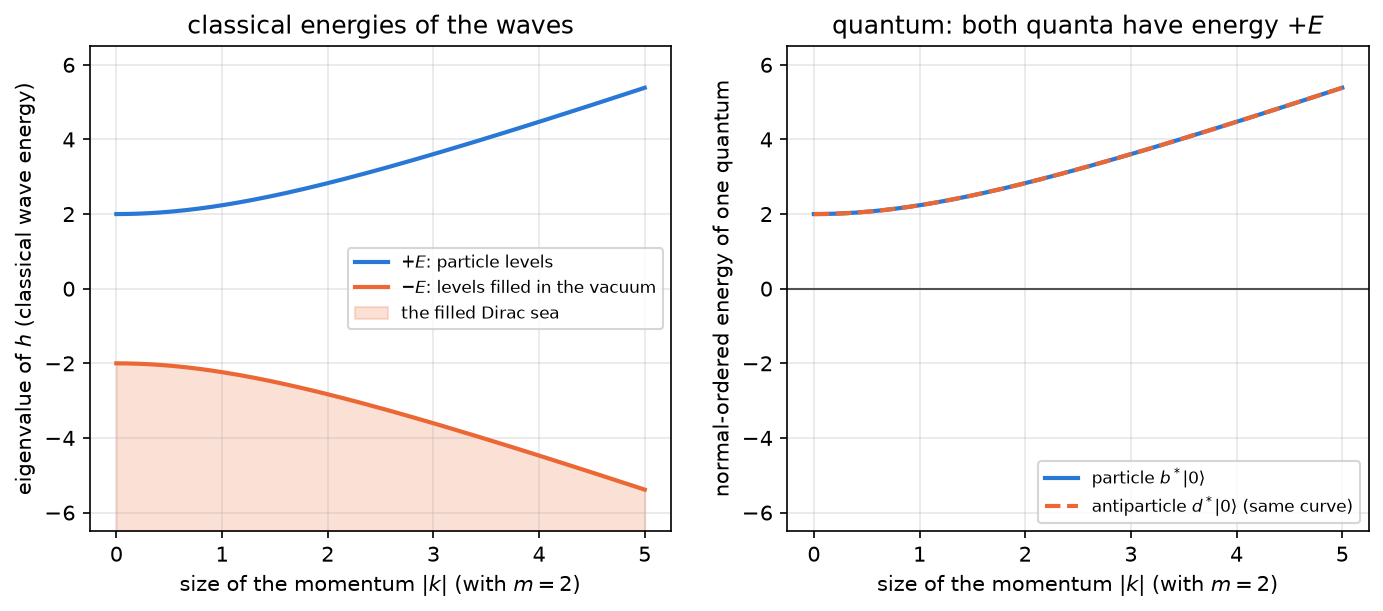

Figure 10c.2 saved as Revision/textbook/figures/10c_2_dirac_sea.png


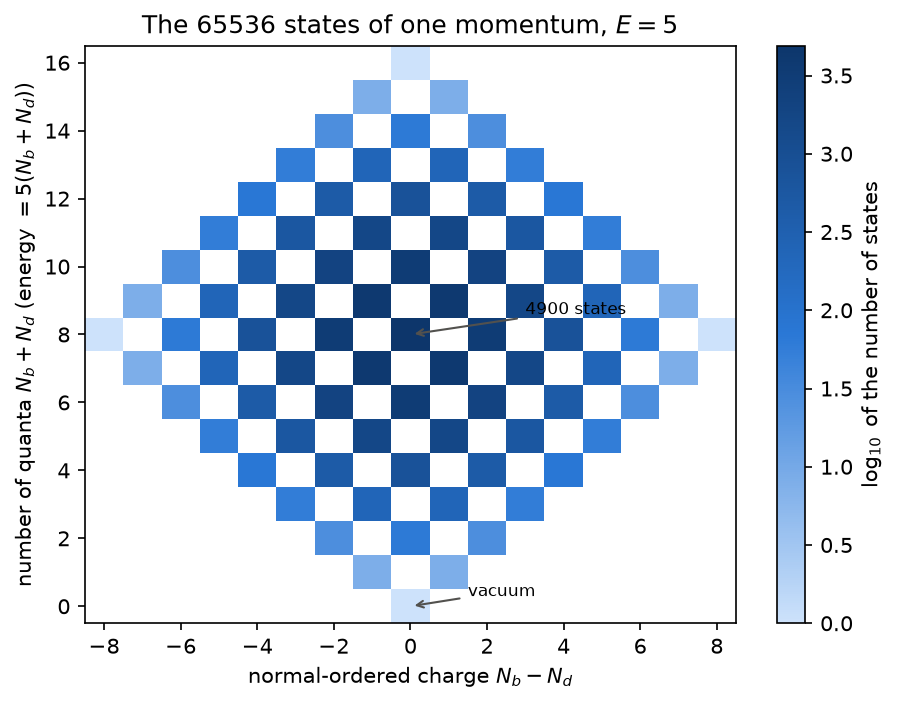

Figure 10c.3 saved as Revision/textbook/figures/10c_3_fock_spectrum.png


In [9]:
k_values = np.linspace(0.0, 5.0, 201)  # the size of the momentum
branch = np.sqrt(2.0 ** 2 + k_values ** 2)  # E for m = 2
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2))
ax = axes[0]
ax.plot(k_values, branch, color=BLUE, linewidth=2, label="$+E$: particle levels")
ax.plot(k_values, -branch, color=ORANGE, linewidth=2,
        label="$-E$: levels filled in the vacuum")
ax.fill_between(k_values, -branch, -6.5, color=ORANGE, alpha=0.2,
                label="the filled Dirac sea")
ax.set_xlabel("size of the momentum $|k|$ (with $m = 2$)")
ax.set_ylabel("eigenvalue of $h$ (classical wave energy)")
ax.set_ylim(-6.5, 6.5)
ax.set_title("classical energies of the waves")
ax.legend(loc="center right", fontsize=8)
ax = axes[1]
ax.plot(k_values, branch, color=BLUE, linewidth=2, label="particle $b^*|0\\rangle$")
ax.plot(k_values, branch, "--", color=ORANGE, linewidth=2,
        label="antiparticle $d^*|0\\rangle$ (same curve)")
ax.axhline(0.0, color=GREY, linewidth=1)
ax.set_xlabel("size of the momentum $|k|$ (with $m = 2$)")
ax.set_ylabel("normal-ordered energy of one quantum")
ax.set_ylim(-6.5, 6.5)
ax.set_title("quantum: both quanta have energy $+E$")
ax.legend(loc="lower right", fontsize=8)
save_figure(fig, "dirac_sea",
            "Left: the eigenvalues $\\pm E = \\pm\\sqrt{m^2 + |k|^2}$ of the "
            "good-sector mode Hamiltonian for $m = 2$ against the size of the "
            "momentum $|k|$ (horizontal axis, same units as $m$); in the vacuum every "
            "negative level is filled (shaded: the Dirac sea), with energy $-8E$ "
            "per momentum. Right: after normal ordering, a particle (blue) and an "
            "antiparticle (orange dashed, on top of the blue curve) both have the "
            "positive energy $+E$; vertical axes in the units of $m$. The good "
            "sector has a positive energy for every quantum.")

from matplotlib.colors import LinearSegmentedColormap  # colour scales

fig, ax = plt.subplots(figsize=(7.0, 5.0))
shown = np.where(counts > 0, np.log10(np.maximum(counts, 1)), np.nan)  # NaN: empty
light_to_dark = LinearSegmentedColormap.from_list(
    "light_to_dark_blue", ["#cde2fb", "#2a78d6", "#0d366b"])  # 1 state is visible
image = ax.imshow(shown, origin="lower", cmap=light_to_dark, aspect="auto",
                  extent=(-8.5, 8.5, -0.5, 16.5))
ax.annotate("vacuum", (0, 0), xytext=(1.5, 0.3), fontsize=8,
            arrowprops={"arrowstyle": "->", "color": GREY})
ax.annotate("4900 states", (0, 8), xytext=(3.0, 8.6), fontsize=8,
            arrowprops={"arrowstyle": "->", "color": GREY})
ax.set_xlabel("normal-ordered charge $N_b - N_d$")
ax.set_ylabel("number of quanta $N_b + N_d$ (energy $= 5(N_b + N_d)$)")
ax.set_title("The 65536 states of one momentum, $E = 5$")
ax.grid(False)
fig.colorbar(image, ax=ax, label="$\\log_{10}$ of the number of states")
save_figure(fig, "fock_spectrum",
            "All $2^{16} = 65536$ quantum states of one good-sector momentum ($m = "
            "2$, $k = (1, 2, 0, 4)$, $E = 5$), sorted by their normal-ordered charge "
            "$N_b - N_d$ (horizontal axis) and their number of quanta $N_b + N_d$ "
            "(vertical axis; the energy is $5(N_b + N_d)$). The colour is the "
            "base-10 logarithm of the number of states in each square (lightest "
            "blue: one state); white squares are empty. The vacuum is the single "
            "state at the bottom; "
            "there are 16 states with one quantum, and the largest number, 4900, "
            "has 8 quanta and charge 0. No state has negative energy.")

## 11. The contrast: the classical commuting field dirac16complex00

The field dirac16complex00 has 16 COMMUTING components and is not quantised. Its
energy density, with the sign convention of the Revision record, is
$\rho = -T^{x_4}{}_{x_4} = -\sum_{\mu \neq x_4}K_\mu + mS$ for $U = 0$, with
$K_\mu = \frac12(\bar\Phi\gamma^{(\mu)}\partial_\mu\Phi - \partial_\mu\bar\Phi
\gamma^{(\mu)}\Phi)$ in flat space and $S = \bar\Phi\Phi$, $\bar\Phi = \Phi^\dagger C$.
For the plane wave $\Phi = c\,u\,e^{i(k\cdot x - Ex_4)}$, line by line:

- $\partial_a\Phi = ik_a\Phi$ and $\partial_a\bar\Phi = -ik_a\bar\Phi$ (the
  conjugate of $e^{ik_ax_a}$ is $e^{-ik_ax_a}$);
- so $K_a = \frac12(ik_a + ik_a)\bar\Phi\gamma^{(x_a)}\Phi = ik_a|c|^2u^\dagger
  C\gamma^{(x_a)}u$, and $S = |c|^2u^\dagger Cu$;
- $\rho = |c|^2u^\dagger(mC - i\sum_a k_aC\gamma^{(x_a)})u = |c|^2u^\dagger h'u$;
- since $Bh' = h$ and $B^2 = I$, $h' = Bh$, and $hu = Eu$ gives $\rho =
  E\,|c|^2\,u^\dagger Bu$.

The charge density is $\Phi^\dagger B\Phi = |c|^2u^\dagger Bu$. In the good sector
$B$ commutes with $h$, so the eigenspace of $+E$ contains 4 columns with $Bu = u$
and 4 with $Bu = -u$ (the inertia $(4, 4)$ of the first notebook). The next cell
finds them (orthonormal columns of the product of the projectors
$\frac12(I + h/E)$ and $\frac12(I \pm B)$), computes $\rho$ directly from the
formula for $K_\mu$ and $S$ (not from the shortcut), and checks the record: for
$|c| = 1$ the energy densities are $+5$ and $-5$ and the charge densities $+1$ and
$-1$.

In [10]:
energy_projector = (np.eye(16) + h / E) / 2  # onto the eigenspace of +E
plus_part = orthonormal_columns(energy_projector @ (np.eye(16) + B) / 2)
minus_part = orthonormal_columns(energy_projector @ (np.eye(16) - B) / 2)
k_sample = {1: 1, 2: 2, 8: 4}  # the momenta of the sample, m = 2


def energy_density(u, m=2.0, k=k_sample):
    """rho = -sum_(a != 4) K_a + m S for Phi = u exp(i(k.x - E x4)), |c| = 1."""
    Phibar = u.conj() @ C  # the row Phi^dagger C at x = 0
    S = (Phibar @ u).real
    K = {a: (0.5 * (Phibar @ gamma[a] @ (1j * k_a * u))
             - 0.5 * ((-1j * k_a) * Phibar) @ gamma[a] @ u) for a, k_a in k.items()}
    return (-sum(K.values()) + m * S).real


densities_plus = [energy_density(plus_part[:, j]) for j in range(plus_part.shape[1])]
densities_minus = [energy_density(minus_part[:, j])
                   for j in range(minus_part.shape[1])]
charge_plus = [(u.conj() @ B @ u).real for u in plus_part.T]
charge_minus = [(u.conj() @ B @ u).real for u in minus_part.T]
say(f"dimensions: {plus_part.shape[1]} with B u = +u, {minus_part.shape[1]} with "
    f"B u = -u")
say(f"energy densities: {np.round(densities_plus, 10).tolist()} and "
    f"{np.round(densities_minus, 10).tolist()}")
say(f"charge densities: {np.round(charge_plus, 10).tolist()} and "
    f"{np.round(charge_minus, 10).tolist()}")
check_record(plus_part.shape[1] == 4 and minus_part.shape[1] == 4
             and np.max(np.abs(np.array(densities_plus) - 5)) < 1e-12
             and np.max(np.abs(np.array(densities_minus) + 5)) < 1e-12
             and np.max(np.abs(np.array(charge_plus) - 1)) < 1e-12
             and np.max(np.abs(np.array(charge_minus) + 1)) < 1e-12,
             "commuting field: positive-frequency waves with energy +5 and -5",
             record="Revision/theory/reports/python-scope.json, check "
                    "commuting_field_energy_unbounded_below")

dimensions: 4 with B u = +u, 4 with B u = -u
energy densities: [5.0, 5.0, 5.0, 5.0] and [-5.0, -5.0, -5.0, -5.0]
charge densities: [1.0, 1.0, 1.0, 1.0] and [-1.0, -1.0, -1.0, -1.0]
PASS commuting field: positive-frequency waves with energy +5 and -5
     reproduces Revision/theory/reports/python-scope.json, check
    commuting_field_energy_unbounded_below


The next cell compares the two fields in a bar chart, and then shows the whole range
of classical energy densities: for 4000 random unit columns $u$ in the eigenspace of
$+E$ (random combinations of its 8 orthonormal columns) the energy density
$\rho = E\,u^\dagger Bu$ of the commuting wave $\Phi = u\,e^{i(k\cdot x - Ex_4)}$.
Since $u^\dagger Bu$ lies between $-1$ and $1$, $\rho$ lies between $-5$ and $5$, and
multiplying $\Phi$ by a number $c$ multiplies $\rho$ by $|c|^2$: the energy of the
classical commuting field is unbounded below.

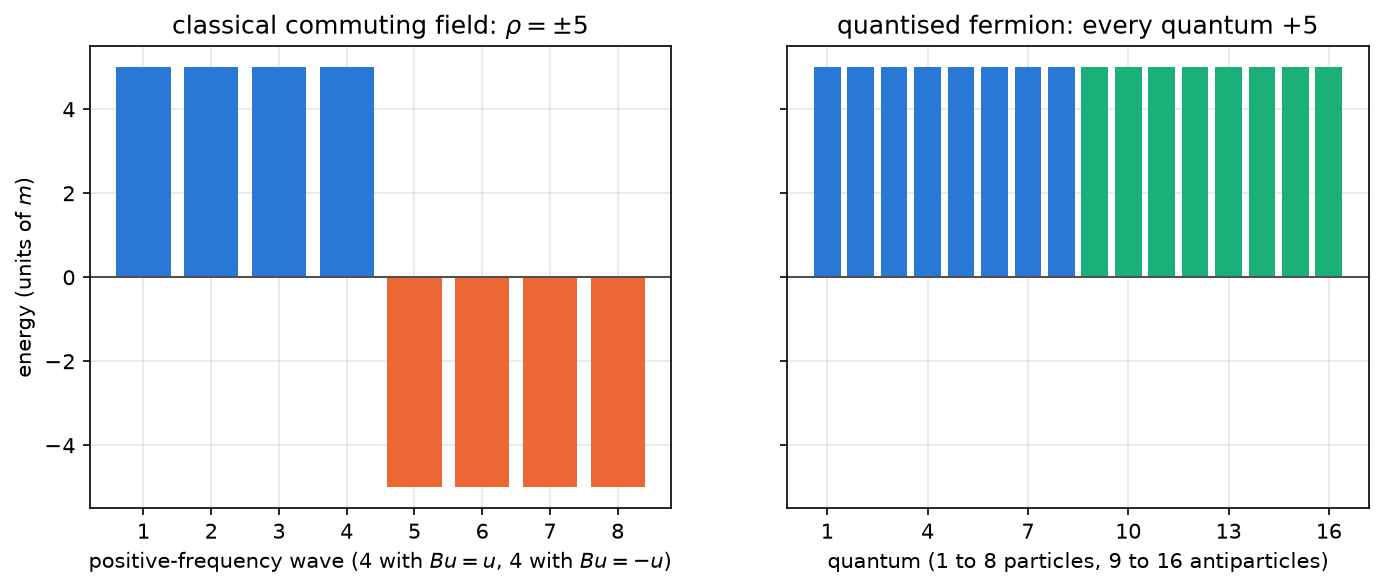

Figure 10c.4 saved as Revision/textbook/figures/10c_4_commuting_energy.png
RESULT smallest and largest energy density of the 4000 waves = -4.364 and 4.333
PASS random positive-frequency commuting waves have energy densities of both signs


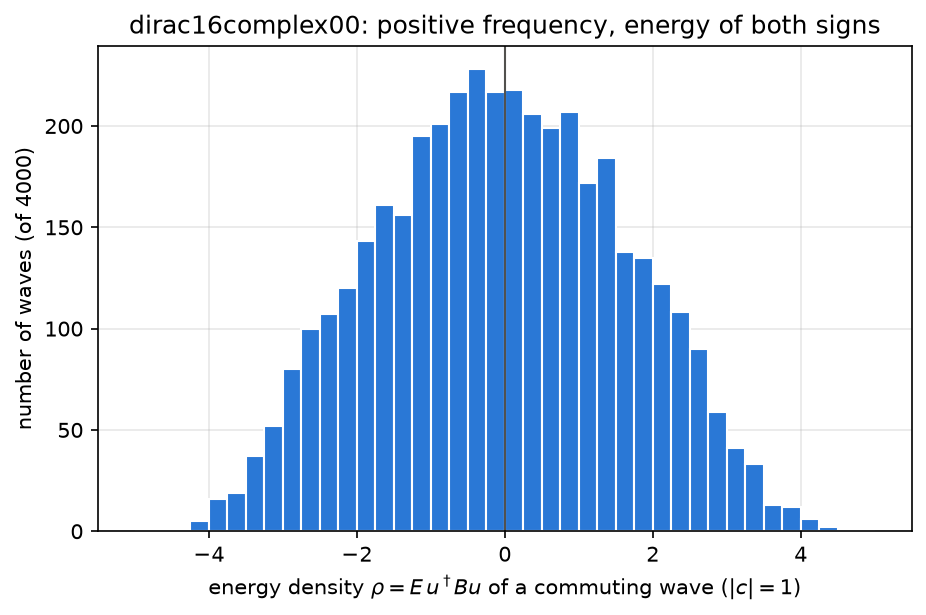

Figure 10c.5 saved as Revision/textbook/figures/10c_5_energy_density_spread.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.0), sharey=True)
for ax in axes:
    ax.set_axisbelow(True)  # draw the grid lines behind the bars
classical = densities_plus + densities_minus
axes[0].bar(range(1, 9), classical,
            color=[BLUE] * len(densities_plus) + [ORANGE] * len(densities_minus))
axes[0].axhline(0.0, color=GREY, linewidth=1)
axes[0].set_xticks(range(1, 9))
axes[0].set_xlabel("positive-frequency wave (4 with $Bu = u$, 4 with $Bu = -u$)")
axes[0].set_ylabel("energy (units of $m$)")
axes[0].set_title("classical commuting field: $\\rho = \\pm 5$")
axes[1].bar(range(1, 17), energies, color=[BLUE] * 8 + [GREEN] * 8)
axes[1].axhline(0.0, color=GREY, linewidth=1)
axes[1].set_xticks(range(1, 17, 3))
axes[1].set_xlabel("quantum (1 to 8 particles, 9 to 16 antiparticles)")
axes[1].set_title("quantised fermion: every quantum $+5$")
save_figure(fig, "commuting_energy",
            "The same momentum $m = 2$, $k = (1, 2, 0, 4)$, $E = 5$ in the two "
            "fields of the theory; vertical axes: energy in units of $m$. Left: "
            "the classical COMMUTING field dirac16complex00, energy density of the 8 "
            "positive-frequency waves $\\Phi = u\\,e^{i(k\\cdot x - 5x_4)}$ of a "
            "basis with $Bu = \\pm u$ ($|c| = 1$): four have $+5$ (blue), four have "
            "$-5$ (orange). Right: the quantised fermion field dirac16complex, "
            "normal-ordered energy of its 16 one-quantum states: $+5$ for each of "
            "the 8 particles (blue) and the 8 antiparticles (green). Quantisation "
            "with anticommutators and normal ordering makes the good-sector energy "
            "positive; the classical commuting field has no such mechanism.")

coefficients = rng.normal(size=(4000, 8)) + 1j * rng.normal(size=(4000, 8))
eigenspace = np.hstack([plus_part, minus_part])  # 8 orthonormal columns
samples = coefficients @ eigenspace.T  # each row: a random column u in the space
samples = samples / np.linalg.norm(samples, axis=1, keepdims=True)
rho = E * np.einsum("ni,ij,nj->n", samples.conj(), B, samples).real
report("smallest and largest energy density of the 4000 waves",
       f"{rho.min():.3f} and {rho.max():.3f}")
check(rho.min() < -2 and rho.max() > 2 and np.all(np.abs(rho) <= 5 + 1e-12),
      "random positive-frequency commuting waves have energy densities of both signs")
fig, ax = plt.subplots()
ax.set_axisbelow(True)
ax.hist(rho, bins=40, range=(-5, 5), color=BLUE, edgecolor="white")
ax.axvline(0.0, color=GREY, linewidth=1)
ax.set_xlabel("energy density $\\rho = E\\,u^\\dagger B u$ of a commuting wave "
              "($|c| = 1$)")
ax.set_ylabel("number of waves (of 4000)")
ax.set_title("dirac16complex00: positive frequency, energy of both signs")
save_figure(fig, "energy_density_spread",
            "Histogram of the energy density $\\rho = E\\,u^\\dagger Bu$ (horizontal "
            "axis, units of $m$, between $-5$ and $5$) of 4000 random "
            "positive-frequency plane waves $\\Phi = u\\,e^{i(k\\cdot x - 5x_4)}$ of "
            "the classical commuting field dirac16complex00 with $m = 2$, $k = (1, "
            "2, 0, 4)$ and $u^\\dagger u = 1$ (vertical axis: number of waves per "
            "bin). About half of the waves have negative energy density; multiplying a "
            "wave by a large number makes its energy as negative as one likes: the "
            "classical energy is unbounded below.")

## 12. The last check

The last cell checks that all five figure files exist in the folder
Revision/textbook/figures and prints the number of checks that passed.

In [12]:
for name in ("10c_1_expectation_rule.png", "10c_2_dirac_sea.png",
             "10c_3_fock_spectrum.png", "10c_4_commuting_energy.png",
             "10c_5_energy_density_spread.png"):
    check(output_file(f"{FIGURE_FOLDER}/{name}").is_file(),
          f"the figure file {name} exists")
all_checks_passed()

PASS the figure file 10c_1_expectation_rule.png exists
PASS the figure file 10c_2_dirac_sea.png exists
PASS the figure file 10c_3_fock_spectrum.png exists
PASS the figure file 10c_4_commuting_energy.png exists
PASS the figure file 10c_5_energy_density_spread.png exists
ALL 14 CHECKS PASSED (notebook 10c)


## 13. What this notebook showed

- CONSTRUCTED and CHECKED (for the two exact examples of the Revision record,
  $m = 2$, $k = (1, 2, 0, 4)$ and $m = 3$, $k_1 = 4$, both with $E = 5$): in the good
  sector the mode Hamiltonian is Hermitian with eigenvalues $\pm E$, the field is
  expanded in particle and antiparticle operators on a POSITIVE Fock space, and with
  $\Psi^\dagger = \chi B$ the canonical rule $\{\Psi, \Psi^\dagger\} = B$ holds.
- The vacuum, the filled Dirac sea, has energy $-8E = -40$ per momentum; after
  normal ordering every particle and every antiparticle has energy $+E$, and their
  charges are $+1$ and $-1$. All 65536 states of one momentum have non-negative
  normal-ordered energy $E(N_b + N_d)$.
- The expectation-value rule: $u^\dagger BMu$ for a particle, $-v^\dagger BMv$ for an
  antiparticle (checked for 100 random matrices and for the matrices of the
  WolframScript record).
- The classical COMMUTING field dirac16complex00 has positive-frequency waves of
  energy density $+5$ and $-5$ for the same momentum: its classical energy is
  unbounded below already for $U = 0$ in the good sector (reproduced), and its
  charge is indefinite. The quantum statements of this chapter concern only the
  fermion field dirac16complex: the author defines dirac16complex00 as a classical
  ("semi-classical") field, and the Revision record does not quantise it.
- SCOPE: the positive Fock space is built for single good-sector momenta with frozen
  coefficients (flat space). A positive-norm Hilbert space for the whole field, the
  extra-time sector with its growing waves, and the interacting theory ($\lambda
  \neq 0$) are not constructed; the next notebook shows what happens in the curved
  good sector of the author's metric without a boundary condition at $z = \pi/2$.